1) Install + imports (Colab / local)

In [1]:
!pip install -q timm albumentations opencv-python scikit-learn matplotlib seaborn

In [2]:
import os, cv2, math, random, numpy as np, pandas as pd
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── mixup helper ─────────────────────────────────────────────────────────────
def mixup_batch(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    bs  = x.size(0)
    idx = torch.randperm(bs, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ════════════════════════════════════════════════════════════════════
# CONFIG  –  all knobs in one place
# ════════════════════════════════════════════════════════════════════
CSV_PATH    = "/content/drive/MyDrive/AURA/final_3000_dataset/final_3000_correct_mapping.csv"
SAVE_DIR    = "/content/drive/MyDrive/AURA/baseline_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

# model
IMG_SIZE    = 300
ARCH        = "efficientnet_b3"

# training
BATCH_SIZE  = 16
NUM_WORKERS = 2          # Colab supports multiple workers
EPOCHS      = 25
LR          = 5e-4
WEIGHT_DECAY= 1e-4
DROP_RATE   = 0.4
LABEL_SMOOTH= 0.10       # smoothing for CrossEntropyLoss
MIXUP_ALPHA = 0.20       # 0 to disable mixup
CLIP_GRAD   = 1.0        # max gradient norm

BEST_PATH   = os.path.join(SAVE_DIR, "effb3_best.pt")

print("SAVE_DIR :", SAVE_DIR)
print("CSV_PATH :", CSV_PATH)
print("device   :", "cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive
SAVE_DIR : /content/drive/MyDrive/AURA/baseline_outputs
CSV_PATH : /content/drive/MyDrive/AURA/final_3000_dataset/final_3000_correct_mapping.csv
device   : cuda


2) Dataset (reads your CSV + image_path + split + drug_group)

Your CSV columns include: image_path, split, drug_group (values: H1_ANTIHISTAMINE, LTRA, ADVANCED_THERAPY, OTHER).

In [4]:
df = pd.read_csv(CSV_PATH)
df["split"] = df["split"].astype(str).str.lower().str.strip()

label_names = sorted(df["drug_group"].unique().tolist())
label2id = {k: i for i, k in enumerate(label_names)}
id2label = {i: k for k, i in label2id.items()}

print("Labels :", label2id)
print(df["split"].value_counts())

Labels : {'ADVANCED_THERAPY': 0, 'H1_ANTIHISTAMINE': 1, 'LTRA': 2, 'OTHER': 3}
split
train         2062
validation     484
test           454
Name: count, dtype: int64


Albumentations transforms

In [5]:
train_tfms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT),
    # geometry
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.10, rotate_limit=12, p=0.6),
    A.Perspective(scale=(0.02, 0.06), p=0.3),
    # photometry – important for clinical prescription images
    A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.4),
    A.GaussNoise(var_limit=(5.0, 30.0), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    # occlusion / dropout
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                    min_holes=1, min_height=8, min_width=8, p=0.35),
    A.Normalize(),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),   # deterministic at inference
    A.Normalize(),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_247/1940034819.py:12: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 30.0), p=0.3),
/tmp/ipykernel_247/1940034819.py:15: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32,


PyTorch Dataset

In [6]:
class CUImageDataset(Dataset):
    def __init__(self, df, label2id, tfms):
        self.df = df.reset_index(drop=True)
        self.label2id = label2id
        self.tfms = tfms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]

        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Could not read image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        x = self.tfms(image=img)["image"]
        y_drug = self.label2id[row["drug_group"]]

        # Optional binary CU/non-CU head later:
        # y_cu = int(row["cu_label"])  # add a column if you have it
        # return x, y_drug, y_cu

        return x, y_drug

3) DataLoaders (with imbalance handling)

In [7]:
train_df = df[df["split"].isin(["train", "training"])].copy()
val_df   = df[df["split"].isin(["val", "validation"])].copy()
test_df  = df[df["split"].isin(["test"])].copy() if (df["split"] == "test").any() else val_df.copy()

train_ds = CUImageDataset(train_df, label2id, train_tfms)
val_ds   = CUImageDataset(val_df,   label2id, val_tfms)
test_ds  = CUImageDataset(test_df,  label2id, val_tfms)

# weighted sampler to address class imbalance
train_labels   = train_df["drug_group"].map(label2id).values
class_counts   = np.bincount(train_labels, minlength=len(label2id))
class_weights  = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

train=2062  val=484  test=454


4) EfficientNet-B3 model (image-only)
A) Single-head (drug_group only)

In [8]:
class GeM(nn.Module):
    """Generalised Mean Pooling – richer than plain avg-pool."""
    def __init__(self, p: float = 3.0, eps: float = 1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(self.p), 1
        ).pow(1.0 / self.p).flatten(1)


class EffB3DrugClassifier(nn.Module):
    """
    EfficientNet-B3 backbone with:
     • GeM pooling  (richer than avg-pool)
     • concat(GeM, AdaptiveMaxPool)  → 2× feature width
     • two-layer MLP head with BN + GELU
    """
    def __init__(self, num_classes: int, drop_rate: float = DROP_RATE):
        super().__init__()
        self.backbone = timm.create_model(
            ARCH, pretrained=True, num_classes=0, global_pool=""
        )
        feat_dim = self.backbone.num_features   # 1536 for B3

        self.gem = GeM()
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        hidden = feat_dim                           # 1536
        self.head = nn.Sequential(
            nn.Linear(feat_dim * 2, hidden),        # concat gem + max → hidden
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Dropout(drop_rate),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        feat_map = self.backbone.forward_features(x)     # (B, C, H, W)
        gem_feat = self.gem(feat_map)                    # (B, C)
        max_feat = self.max_pool(feat_map).flatten(1)    # (B, C)
        feat     = torch.cat([gem_feat, max_feat], dim=1)  # (B, 2C)
        return self.head(feat)

B) Multi-head (drug_group + optional CU/non-CU)

If you later add a cu_label column (0/1), use this version:

In [9]:
class EffB3MultiHead(nn.Module):
    def __init__(self, num_drug_classes: int, use_cu_head: bool = False):
        super().__init__()
        self.use_cu_head = use_cu_head
        self.backbone = timm.create_model("efficientnet_b3", pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features

        self.drug_head = nn.Sequential(nn.Dropout(0.3), nn.Linear(feat_dim, num_drug_classes))
        self.cu_head   = nn.Sequential(nn.Dropout(0.3), nn.Linear(feat_dim, 1)) if use_cu_head else None

    def forward(self, x):
        f = self.backbone(x)
        out = {"drug_logits": self.drug_head(f)}
        if self.use_cu_head:
            out["cu_logit"] = self.cu_head(f).squeeze(1)
        return out

5) Training loop (AMP + early save best)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Training on:", device)

model = EffB3DrugClassifier(num_classes=len(label2id)).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# OneCycleLR – peaks at epoch ~5, then anneals cosine-style → helps convergence
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.2,
    anneal_strategy="cos",
)

# weighted loss + label smoothing
train_labels_arr = train_df["drug_group"].map(label2id).values
cls_counts  = np.bincount(train_labels_arr, minlength=len(label2id))
cls_w       = torch.tensor(1.0 / np.maximum(cls_counts, 1), dtype=torch.float).to(device)
cls_w       = cls_w / cls_w.sum() * len(label2id)   # normalise
criterion   = nn.CrossEntropyLoss(weight=cls_w, label_smoothing=LABEL_SMOOTH)

scaler = torch.amp.GradScaler(enabled=(device == "cuda"))

# ── per-epoch history ─────────────────────────────────────────────────────────
history = {"tr_loss": [], "tr_acc": [], "tr_f1": [],
           "va_loss": [], "va_acc": [], "va_f1": [], "lr": []}

def run_epoch(loader, train: bool):
    model.train(train)
    all_y, all_p, total_loss = [], [], 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if train and MIXUP_ALPHA > 0:
            x, y_a, y_b, lam = mixup_batch(x, y, MIXUP_ALPHA)
        else:
            y_a, y_b, lam = y, y, 1.0

        with torch.amp.autocast(device_type=device, enabled=(device == "cuda")):
            logits = model(x)
            loss   = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)

        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        all_y.append(y.detach().cpu().numpy())
        all_p.append(preds.detach().cpu().numpy())

    all_y    = np.concatenate(all_y)
    all_p    = np.concatenate(all_p)
    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_y, all_p)
    f1       = f1_score(all_y, all_p, average="macro", zero_division=0)
    return avg_loss, acc, f1

# ── training loop ─────────────────────────────────────────────────────────────
best_f1 = -1.0

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    va_loss, va_acc, va_f1 = run_epoch(val_loader,   train=False)
    cur_lr = scheduler.get_last_lr()[0]

    history["tr_loss"].append(tr_loss);  history["va_loss"].append(va_loss)
    history["tr_acc"].append(tr_acc);    history["va_acc"].append(va_acc)
    history["tr_f1"].append(tr_f1);      history["va_f1"].append(va_f1)
    history["lr"].append(cur_lr)

    flag = ""
    if va_f1 > best_f1:
        best_f1 = va_f1
        torch.save({
            "model_state": model.state_dict(),
            "label2id": label2id,
            "id2label":  id2label,
            "img_size":  IMG_SIZE,
            "arch":      ARCH,
        }, BEST_PATH)
        flag = "  ✅ best saved"

    print(f"ep{ep:02d}  "
          f"tr loss={tr_loss:.4f} acc={tr_acc:.3f} f1={tr_f1:.3f} | "
          f"va loss={va_loss:.4f} acc={va_acc:.3f} f1={va_f1:.3f} | "
          f"lr={cur_lr:.2e}{flag}")

print(f"\nBest val macro-F1: {best_f1:.4f}")

Training on: cuda


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

/tmp/ipykernel_247/4177502733.py:55: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


ep01  tr loss=1.3687 acc=0.275 f1=0.239 | va loss=2.1048 acc=0.091 f1=0.067 | lr=6.60e-05  ✅ best saved
ep02  tr loss=1.3497 acc=0.268 f1=0.203 | va loss=2.4582 acc=0.132 f1=0.113 | lr=1.86e-04  ✅ best saved
ep03  tr loss=1.3743 acc=0.279 f1=0.221 | va loss=2.4021 acc=0.122 f1=0.121 | lr=3.35e-04  ✅ best saved
ep04  tr loss=1.3299 acc=0.265 f1=0.208 | va loss=2.0415 acc=0.165 f1=0.164 | lr=4.55e-04  ✅ best saved
ep05  tr loss=1.2843 acc=0.288 f1=0.217 | va loss=2.9000 acc=0.114 f1=0.100 | lr=5.00e-04
ep06  tr loss=1.2762 acc=0.289 f1=0.225 | va loss=2.2661 acc=0.134 f1=0.123 | lr=4.97e-04
ep07  tr loss=1.2603 acc=0.280 f1=0.223 | va loss=1.8691 acc=0.126 f1=0.129 | lr=4.88e-04
ep08  tr loss=1.2724 acc=0.285 f1=0.215 | va loss=2.1289 acc=0.114 f1=0.117 | lr=4.73e-04
ep09  tr loss=1.2508 acc=0.316 f1=0.249 | va loss=1.9785 acc=0.180 f1=0.184 | lr=4.52e-04  ✅ best saved
ep10  tr loss=1.2391 acc=0.279 f1=0.211 | va loss=2.1015 acc=0.136 f1=0.139 | lr=4.27e-04
ep11  tr loss=1.1887 acc=0.324

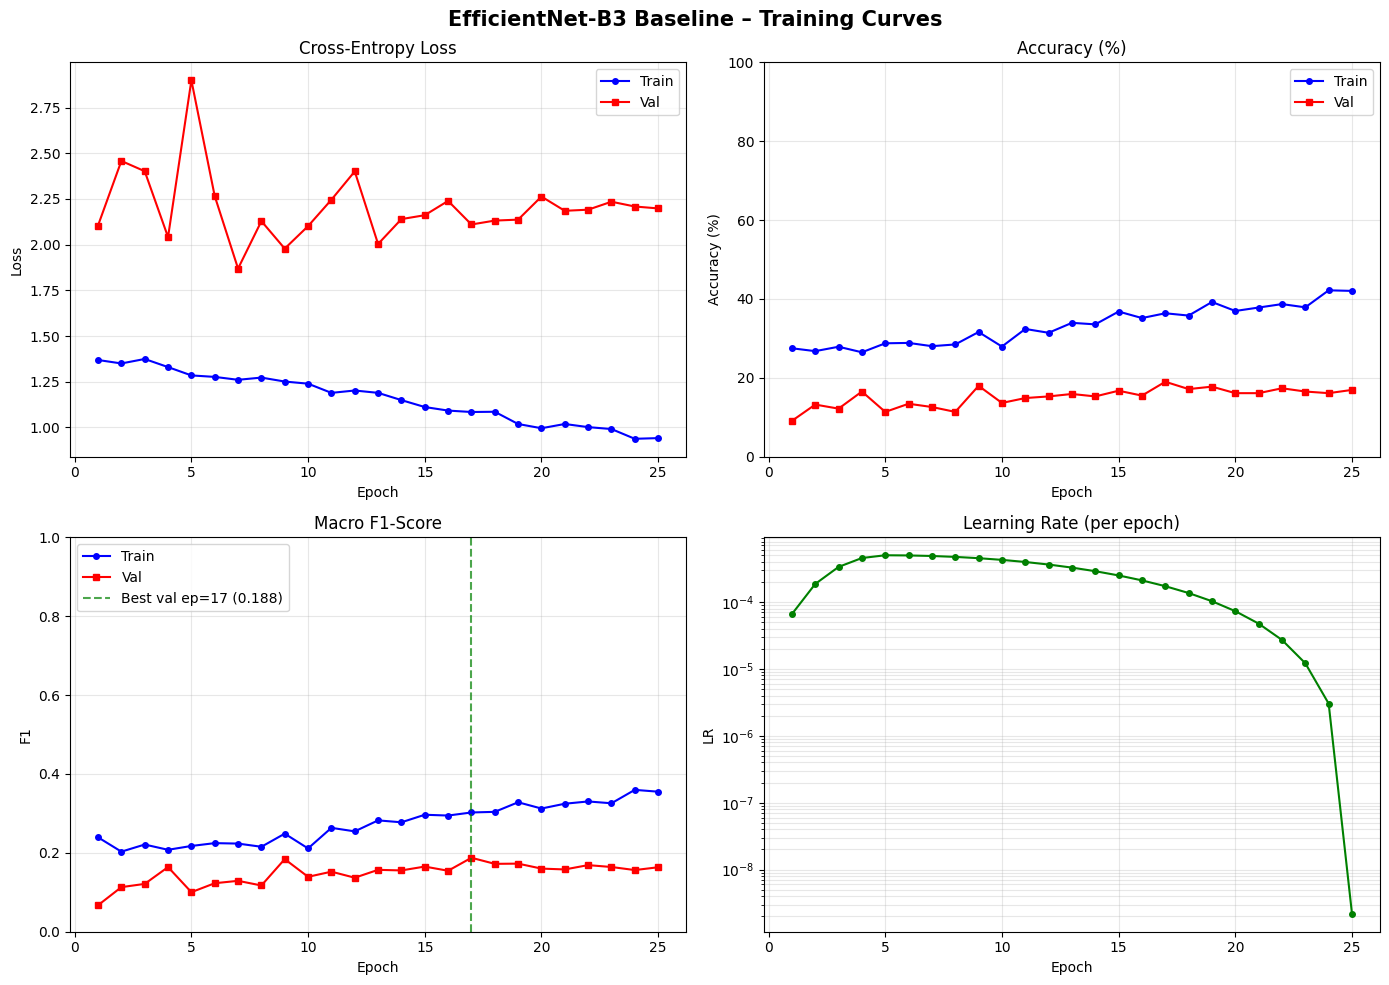

Saved: /content/drive/MyDrive/AURA/baseline_outputs/training_curves.png


In [11]:
# ════════════════════════════════════════════════════════════════════
# Plot 1 – Training Curves (loss / accuracy / macro-F1 / LR)
# ════════════════════════════════════════════════════════════════════
epochs_range = range(1, len(history["tr_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EfficientNet-B3 Baseline – Training Curves", fontsize=15, fontweight="bold")

# --- Loss ---
ax = axes[0, 0]
ax.plot(epochs_range, history["tr_loss"], "b-o", ms=4, label="Train")
ax.plot(epochs_range, history["va_loss"], "r-s", ms=4, label="Val")
ax.set_title("Cross-Entropy Loss")
ax.set_xlabel("Epoch");  ax.set_ylabel("Loss")
ax.legend();  ax.grid(alpha=0.3)

# --- Accuracy ---
ax = axes[0, 1]
ax.plot(epochs_range, [v * 100 for v in history["tr_acc"]], "b-o", ms=4, label="Train")
ax.plot(epochs_range, [v * 100 for v in history["va_acc"]], "r-s", ms=4, label="Val")
ax.set_title("Accuracy (%)")
ax.set_xlabel("Epoch");  ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100);  ax.legend();  ax.grid(alpha=0.3)

# --- Macro-F1 ---
ax = axes[1, 0]
ax.plot(epochs_range, history["tr_f1"], "b-o", ms=4, label="Train")
ax.plot(epochs_range, history["va_f1"], "r-s", ms=4, label="Val")
best_ep = int(np.argmax(history["va_f1"])) + 1
ax.axvline(best_ep, color="green", linestyle="--", alpha=0.7,
           label=f"Best val ep={best_ep} ({max(history['va_f1']):.3f})")
ax.set_title("Macro F1-Score")
ax.set_xlabel("Epoch");  ax.set_ylabel("F1")
ax.set_ylim(0, 1);  ax.legend();  ax.grid(alpha=0.3)

# --- Learning rate ---
ax = axes[1, 1]
ax.plot(epochs_range, history["lr"], "g-o", ms=4)
ax.set_title("Learning Rate (per epoch)")
ax.set_xlabel("Epoch");  ax.set_ylabel("LR")
ax.set_yscale("log");  ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plot_path = os.path.join(SAVE_DIR, "training_curves.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)

6) Test + report

In [12]:
# ── reload best checkpoint ────────────────────────────────────────────────────
ckpt = torch.load(BEST_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()

all_y, all_p = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_p.append(preds)
        all_y.append(y.numpy())

all_y = np.concatenate(all_y)
all_p = np.concatenate(all_p)

test_acc = accuracy_score(all_y, all_p)
test_f1  = f1_score(all_y, all_p, average="macro", zero_division=0)
class_names = [id2label[i] for i in range(len(id2label))]

print(f"Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test Macro-F1  : {test_f1:.4f}")
print()
print(classification_report(all_y, all_p, target_names=class_names, zero_division=0))

Test Accuracy  : 0.1674  (16.74%)
Test Macro-F1  : 0.1583

                  precision    recall  f1-score   support

ADVANCED_THERAPY       0.13      0.27      0.17        64
H1_ANTIHISTAMINE       0.00      0.00      0.00       230
            LTRA       0.10      0.33      0.16        46
           OTHER       0.25      0.39      0.30       114

        accuracy                           0.17       454
       macro avg       0.12      0.24      0.16       454
    weighted avg       0.09      0.17      0.12       454



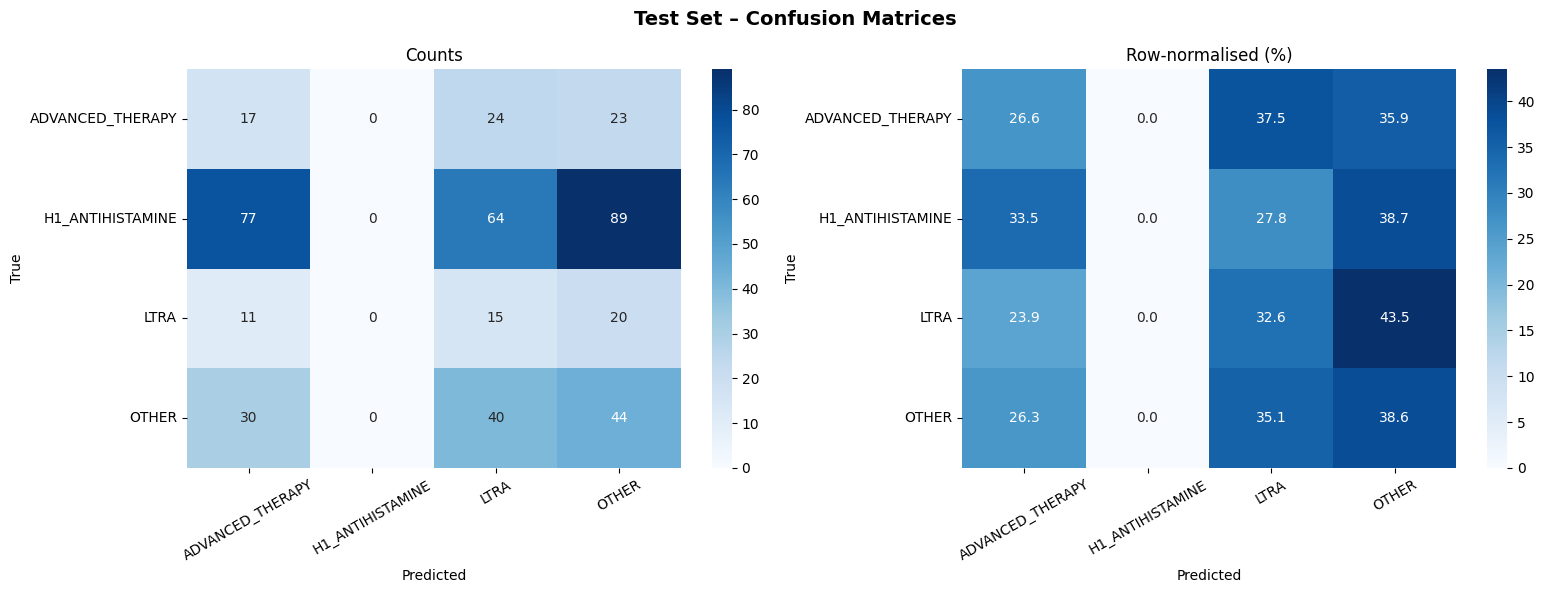

Saved: /content/drive/MyDrive/AURA/baseline_outputs/confusion_matrix.png


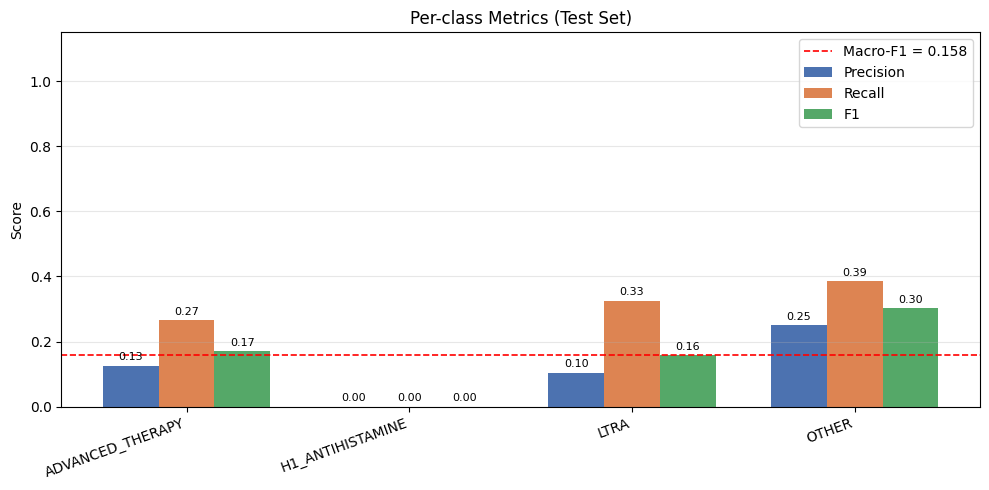

Saved: /content/drive/MyDrive/AURA/baseline_outputs/per_class_metrics.png


In [13]:
# ════════════════════════════════════════════════════════════════════
# Plot 2 – Confusion Matrix
# ════════════════════════════════════════════════════════════════════
cm = confusion_matrix(all_y, all_p)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row-normalised %

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Test Set – Confusion Matrices", fontsize=14, fontweight="bold")

# absolute counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Counts")
axes[0].set_xlabel("Predicted");  axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=30)

# row-normalised %
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Row-normalised (%)")
axes[1].set_xlabel("Predicted");  axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", cm_path)

# ════════════════════════════════════════════════════════════════════
# Plot 3 – Per-class Precision / Recall / F1 bar chart
# ════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1_per, support = precision_recall_fscore_support(
    all_y, all_p, zero_division=0
)
x_idx = np.arange(len(class_names))
bar_w = 0.25

fig, ax = plt.subplots(figsize=(max(10, len(class_names) * 2), 5))
ax.bar(x_idx - bar_w, prec, bar_w, label="Precision", color="#4c72b0")
ax.bar(x_idx,         rec,  bar_w, label="Recall",    color="#dd8452")
ax.bar(x_idx + bar_w, f1_per, bar_w, label="F1",      color="#55a868")

for xi, (p, r, f) in enumerate(zip(prec, rec, f1_per)):
    ax.text(xi - bar_w, p + 0.01, f"{p:.2f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi,         r + 0.01, f"{r:.2f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi + bar_w, f + 0.01, f"{f:.2f}", ha="center", va="bottom", fontsize=8)

ax.axhline(test_f1, color="red", linestyle="--", linewidth=1.2,
           label=f"Macro-F1 = {test_f1:.3f}")
ax.set_xticks(x_idx);  ax.set_xticklabels(class_names, rotation=20, ha="right")
ax.set_ylim(0, 1.15);  ax.set_ylabel("Score");  ax.set_title("Per-class Metrics (Test Set)")
ax.legend(loc="upper right");  ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
bar_path = os.path.join(SAVE_DIR, "per_class_metrics.png")
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", bar_path)

8) “Prescription generation” output (simple)

For image-only, treat “prescription generation” as predicting:
drug_group (your current column) OR
guideline step (if you have it as a label)
Then at inference time you map class → recommended group.


In [14]:
def predict_drug_group(img_path: str):
    model.eval()
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    x = val_tfms(image=img)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = int(logits.argmax(dim=1).item())
    return id2label[pred]